In [14]:
import pandas as pd
import glob
import numpy as np

In [6]:
dir_list = glob.glob("D:/data/GOES/K0/G0*.gz")
cols = {'Year':None, 'DOY':None, 'Hour':None, 'Minute':None,
            'IMF_id':99, 'SW_id':99, 'IMF_pt':999, 'SW_pt':999,
            'Per_int':999, 'Timeshift':999999, 'RMS_Timeshift':999999,
            'RMS_PhaseFrontNormal':99.99, 'Time_btwn_observations':999999,
            'B':9999.99, 'Bx_GSEGSM':9999.99, 'By_GSE':9999.99, 'Bz_GSE':9999.99,
            'By_GSM':9999.99, 'Bz_GSM':9999.99, 'RMS_SD_B':9999.99,
            'RMS_SD_field_vector':9999.99, 'Vsw':99999.9, 'Vx_GSE':99999.9,
            'Vy_GSE':99999.9, 'Vz_GSE':99999.9, 'Prho':999.99,'Tp':9999999.,
            'dynP':99.99, 'Esw':999.99, 'Beta':999.99, 'AlfvenMach':999.9,
            'X(s/c), GSE':9999.99, 'Y(s/c), GSE':9999.99, 'Z(s/c), GSE':9999.99,
            'BSN location, Xgse':9999.99, 'BSN location, Ygse':9999.99, 'BSN location, Zgse':9999.99,
            'AE':99999, 'AL':99999, 'AU':99999, 'SYM_D index':99999, 'SYM_H index':99999, 
            'ASY_D index':99999, 'ASY_H index':99999, 'PC index':999.99, 'Na_Np Ratio':9.999,
            'MagnetosonicMach':99.9}

In [7]:
dir_list

['D:/data/GOES/K0\\G0_K0_EP8_235869.txt1.gz',
 'D:/data/GOES/K0\\G0_K0_EP8_238529.txt1.gz',
 'D:/data/GOES/K0\\G0_K0_EP8_241341.txt1.gz',
 'D:/data/GOES/K0\\G0_K0_EP8_247195.txt1.gz']

In [8]:
gs_dat = pd.concat((pd.read_csv(f,sep='\s+', skipinitialspace=True, comment='#', skiprows=5,on_bad_lines='skip', header=2)
                   for f in dir_list), 
                     ignore_index=True)

gs_dat = gs_dat.rename({'e/(cm^2*s*sr)':'>0.6 MeV','e/(cm^2*s*sr).1':'>2 MeV','e/(cm^2*s*sr).2':'>4 Mev', 
                        'km':'GSE X', 'km.1':'GSE Y', 'km.2':'GSE Z'},axis='columns')

In [9]:
gs_dat['DateTime'] = pd.to_datetime(gs_dat['dd-mm-yyyy']+gs_dat['hh:mm:ss.ms'], format='%d-%m-%Y%H:%M:%S.%f')

In [10]:
gs_dat = gs_dat.sort_values('DateTime').reset_index()

In [12]:
gs_dat.describe()

,index,>0.6 MeV,>2 MeV,>4 Mev,GSE X,GSE Y,GSE Z,DateTime
count,720576.000000,7.205760e+05,7.205760e+05,7.205760e+05,720576.000000,720576.000000,720576.000000,720576
mean,360287.500000,-6.271372e+28,-6.257494e+28,-1.000000e+31,-17.412195,-3.181291,0.212137,2002-09-20 17:25:45.323739392
min,0.000000,-1.000000e+31,-1.000000e+31,-1.000000e+31,-42181.100000,-42178.300000,-16851.400000,1999-03-21 00:02:30
25%,180143.750000,5.132367e+04,3.306600e+01,-1.000000e+31,-28586.775000,-28551.025000,-11866.700000,2000-12-16 12:01:15
50%,360287.500000,1.597700e+05,2.217300e+02,-1.000000e+31,-21.807900,-4.109235,-0.851248,2002-09-06 00:00:00
75%,540431.250000,3.971700e+05,1.418342e+03,-1.000000e+31,28553.575000,28542.225000,11867.500000,2004-05-26 11:58:45
max,720575.000000,2.713160e+06,3.197120e+05,-1.000000e+31,42159.200000,42164.900000,16861.800000,2006-06-22 23:57:30
std,208012.518124,7.894334e+29,7.885649e+29,1.094668e+20,28621.280729,28596.758196,11866.959558,NaN


In [15]:
bd_1 = gs_dat['>0.6 MeV'] < 0
bd_2 = gs_dat['>2 MeV'] < 0
bd_3 = gs_dat['>4 Mev'] < 0

gs_dat.loc[bd_1, '>0.6 MeV'] = np.nan
gs_dat.loc[bd_2, '>2 MeV'] = np.nan
gs_dat.loc[bd_3, '>4 Mev'] = np.nan

In [16]:
fn = f'D:\\data\\goes_omni_1999_2010.hdf5'
dat = pd.read_hdf(fn)

In [19]:
dat.columns

Index(['dd-mm-yyyy', 'hh:mm:ss.ms', '>0.6 MeV', '>2 MeV', '>4 Mev', 'GSE X',
       'GSE Y', 'GSE Z', 'DateTime', 'Year', 'DOY', 'Hour', 'Minute', 'IMF_id',
       'SW_id', 'IMF_pt', 'SW_pt', 'Per_int', 'Timeshift', 'RMS_Timeshift',
       'RMS_PhaseFrontNormal', 'Time_btwn_observations', 'B', 'Bx_GSEGSM',
       'By_GSE', 'Bz_GSE', 'By_GSM', 'Bz_GSM', 'RMS_SD_B',
       'RMS_SD_field_vector', 'Vsw', 'Vx_GSE', 'Vy_GSE', 'Vz_GSE', 'Prho',
       'Tp', 'dynP', 'Esw', 'Beta', 'AlfvenMach', 'X(s/c), GSE', 'Y(s/c), GSE',
       'Z(s/c), GSE', 'BSN location, Xgse', 'BSN location, Ygse',
       'BSN location, Zgse', 'AE', 'AL', 'AU', 'SYM_D index', 'SYM_H index',
       'ASY_D index', 'ASY_H index', 'PC index', 'Na_Np Ratio',
       'MagnetosonicMach', 'DateTime_omni', 'storm', 'storm phase'],
      dtype='object')

In [21]:
dat = dat.drop(['dd-mm-yyyy', 'hh:mm:ss.ms', '>0.6 MeV', '>2 MeV', '>4 Mev', 'GSE X',
       'GSE Y', 'GSE Z'], axis=1)

In [23]:
dat = dat.drop('DateTime',axis=1)

In [24]:
dat.head()

,Year,DOY,Hour,Minute,IMF_id,SW_id,IMF_pt,SW_pt,Per_int,Timeshift,...,SYM_D index,SYM_H index,ASY_D index,ASY_H index,PC index,Na_Np Ratio,MagnetosonicMach,DateTime_omni,storm,storm phase
DateTime,,,,,,,,,,,,,,,,,,,,,
1999-03-21 00:02:30,1999,80,0,2,50.0,NaN,5.0,NaN,100.0,574.0,...,-4.0,-10.0,22.0,19.0,-0.29,99.9,NaN,1999-03-21 00:02:00,-1,-1
1999-03-21 00:07:30,1999,80,0,7,50.0,NaN,5.0,NaN,0.0,586.0,...,-4.0,-11.0,23.0,20.0,-0.27,99.9,NaN,1999-03-21 00:07:00,-1,-1
1999-03-21 00:12:30,1999,80,0,12,50.0,NaN,5.0,NaN,80.0,601.0,...,-4.0,-10.0,23.0,18.0,-0.29,99.9,NaN,1999-03-21 00:12:00,-1,-1
1999-03-21 00:17:30,1999,80,0,17,50.0,NaN,5.0,NaN,100.0,569.0,...,-4.0,-10.0,22.0,18.0,-0.15,99.9,NaN,1999-03-21 00:17:00,-1,-1
1999-03-21 00:22:30,1999,80,0,22,50.0,50.0,5.0,1.0,100.0,544.0,...,-4.0,-10.0,21.0,19.0,-0.09,4.6,NaN,1999-03-21 00:22:00,-1,-1


In [25]:
tol = pd.Timedelta('30 second')
database = pd.merge_asof(left=gs_dat.set_index('DateTime'),right=dat.set_index('DateTime_omni'),right_index=True,left_index=True,direction='nearest',tolerance=tol)

In [26]:
database

,index,dd-mm-yyyy,hh:mm:ss.ms,>0.6 MeV,>2 MeV,>4 Mev,GSE X,GSE Y,GSE Z,Year,...,AU,SYM_D index,SYM_H index,ASY_D index,ASY_H index,PC index,Na_Np Ratio,MagnetosonicMach,storm,storm phase
DateTime,,,,,,,,,,,,,,,,,,,,,
1999-03-21 00:02:30,536256,21-03-1999,00:02:30.000,45321.8,52.0909,NaN,30891.2,26282.9,-11469.6,1999,...,13.0,-4.0,-10.0,22.0,19.0,-0.29,99.9,NaN,-1,-1
1999-03-21 00:07:30,536257,21-03-1999,00:07:30.000,46472.4,43.6577,NaN,30258.1,26895.1,-11735.6,1999,...,14.0,-4.0,-11.0,23.0,20.0,-0.27,99.9,NaN,-1,-1
1999-03-21 00:12:30,536258,21-03-1999,00:12:30.000,44925.9,46.2486,NaN,29610.6,27494.5,-11995.9,1999,...,14.0,-4.0,-10.0,23.0,18.0,-0.29,99.9,NaN,-1,-1
1999-03-21 00:17:30,536259,21-03-1999,00:17:30.000,43575.8,45.9818,NaN,28948.9,28081.0,-12250.5,1999,...,15.0,-4.0,-10.0,22.0,18.0,-0.15,99.9,NaN,-1,-1
1999-03-21 00:22:30,536260,21-03-1999,00:22:30.000,43315.3,42.8915,NaN,28273.6,28653.9,-12499.2,1999,...,18.0,-4.0,-10.0,21.0,19.0,-0.09,4.6,NaN,-1,-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2006-06-22 23:37:30,117787,22-06-2006,23:37:30.000,264955.0,1033.0400,NaN,30213.1,26672.4,-12356.3,2006,...,10.0,-1.0,-1.0,17.0,15.0,-0.09,6.2,NaN,-1,-1
2006-06-22 23:42:30,117788,22-06-2006,23:42:30.000,247743.0,978.2420,NaN,29678.3,27378.4,-12105.5,2006,...,9.0,-1.0,-2.0,17.0,16.0,0.02,99.9,NaN,-1,-1
2006-06-22 23:47:30,117789,22-06-2006,23:47:30.000,262597.0,1009.3700,NaN,29129.6,28071.2,-11849.0,2006,...,7.0,-1.0,-2.0,16.0,16.0,0.10,6.1,NaN,-1,-1


In [27]:
fn = f'D:\\data\\goes10_omni_1999_2010.hdf5'
database.to_hdf(fn,key='database', mode='w', format='table', complevel=7)

In [31]:
import os

In [29]:
sdate = pd.to_datetime('2000')
edate = pd.to_datetime('2010')

In [32]:
http_path = 'https://spdf.gsfc.nasa.gov/pub/data/omni/high_res_omni/'
sdate = gs_dat['DateTime'].min()
edate = gs_dat['DateTime'].max()
d_ser = pd.date_range(start=sdate, end=edate, freq='12MS')
fn = [os.path.join(http_path,f'omni_min{x.year}.asc') for x in d_ser]

fn

['https://spdf.gsfc.nasa.gov/pub/data/omni/high_res_omni/omni_min1999.asc',
 'https://spdf.gsfc.nasa.gov/pub/data/omni/high_res_omni/omni_min2000.asc',
 'https://spdf.gsfc.nasa.gov/pub/data/omni/high_res_omni/omni_min2001.asc',
 'https://spdf.gsfc.nasa.gov/pub/data/omni/high_res_omni/omni_min2002.asc',
 'https://spdf.gsfc.nasa.gov/pub/data/omni/high_res_omni/omni_min2003.asc',
 'https://spdf.gsfc.nasa.gov/pub/data/omni/high_res_omni/omni_min2004.asc',
 'https://spdf.gsfc.nasa.gov/pub/data/omni/high_res_omni/omni_min2005.asc',
 'https://spdf.gsfc.nasa.gov/pub/data/omni/high_res_omni/omni_min2006.asc']

In [64]:
om_dat = pd.concat((pd.read_csv(f,sep='\s+', engine='python', names=list(cols.keys()), 
                    header=None, on_bad_lines='skip') for f in fn), ignore_index=True)

In [67]:
om_dat.head()

,Year,DOY,Hour,Minute,IMF_id,SW_id,IMF_pt,SW_pt,Per_int,Timeshift,...,AE,AL,AU,SYM_D index,SYM_H index,ASY_D index,ASY_H index,PC index,Na_Np Ratio,MagnetosonicMach
0,1999,1,0,0,51,51,4,1,0,24,...,21,1,22,3,5,7,8,0.04,5.4,NaN
1,1999,1,0,1,51,51,7,1,0,-2,...,20,2,22,3,5,7,8,0.06,5.4,NaN
2,1999,1,0,2,51,51,6,1,0,248,...,21,2,23,3,5,7,9,0.05,5.5,NaN
3,1999,1,0,3,51,51,6,1,0,-50,...,25,0,25,3,5,7,8,0.11,5.3,NaN
4,1999,1,0,4,51,51,6,2,0,-53,...,33,-7,26,3,5,7,8,0.16,5.0,NaN


In [ ]:
pd.to_datetime(om_dat['Year']+om_dat['DOY']+om_dat['Hour']+om_dat['Minute'],format='%Y%j%H%M')

In [71]:
dates=['Year','DOY','Hour','Minute']
dv = om_dat.loc[:,dates].astype('int32')
dt = [f"{x['Year']:04}{x['DOY']:03}{x['Hour']:02}{x['Minute']:02}" for index, x in dv.iterrows()]

In [74]:
om_dat['DateTime'] = pd.to_datetime(dt, format='%Y%j%H%M')

In [75]:
om_dat = om_dat.sort_values('DateTime').reset_index()

In [79]:
om_dat = om_dat.rename(columns={'DateTime':'DateTime_omni'})
om_dat.index = om_dat['DateTime_omni']

gs_dat.index = gs_dat['DateTime']
gs_dat = gs_dat.sort_index()

In [80]:
tol = pd.Timedelta('30 second')
database = pd.merge_asof(left=gs_dat,right=om_dat,right_index=True,left_index=True,direction='nearest',tolerance=tol)

In [87]:
database = database.drop('index',axis=1)

In [89]:
fn = f'D:\\data\\goes_omni_1999_2010.hdf5'
database.to_hdf(fn,key='database', mode='w', format='table', complevel=7)

In [ ]:
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

# remove bad data and replace with NaN
for k, kval in cols.items():
    if kval is None:
        continue
    dat.loc[dat[k] == kval, k] = np.nan

In [125]:
# get storm times

# read in storm start and end times
storm_txt = 'D:\\GitHub\\SatDrag\\data\\storms_drag_epochs_no_overlap.txt'
storm_time = pd.read_csv(storm_txt, header=None, skiprows=1, 
                     delim_whitespace=1, names = ['t_st','t_dst','t_en'], parse_dates=[0, 1, 2],
                     infer_datetime_format=True)

storm_time['t_st'].min()
storm_time['t_st'].max()

C:\Users\krmurph1\AppData\Local\Temp\ipykernel_31392\1068670718.py:5: FutureWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  storm_time = pd.read_csv(storm_txt, header=None, skiprows=1,
C:\Users\krmurph1\AppData\Local\Temp\ipykernel_31392\1068670718.py:5: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  storm_time = pd.read_csv(storm_txt, header=None, skiprows=1,


Timestamp('2017-12-02 01:00:00')

In [126]:
storm_time.tail()

,t_st,t_dst,t_en
438,2017-10-11 05:00:00,2017-10-14 05:00:00,2017-10-18 21:00:00
439,2017-10-23 22:00:00,2017-10-26 14:00:00,2017-10-27 15:00:00
440,2017-11-05 06:00:00,2017-11-08 01:00:00,2017-11-12 22:00:00
441,2017-11-18 14:00:00,2017-11-21 06:00:00,2017-11-24 17:00:00
442,2017-12-02 01:00:00,2017-12-04 20:00:00,2017-12-08 22:00:00


In [128]:
# loop through the storms and set
# flags in the satellite drag database
# for the different times

dat['storm'] = -1
dat['storm phase'] = -1

for index, row in storm_time.iterrows():
    stp = (dat['DateTime']>=row['t_st']) & (dat['DateTime']<row['t_en'])
    mpp = (dat['DateTime']>=row['t_st']) & (dat['DateTime']<row['t_dst'])
    rpp = (dat['DateTime']>=row['t_dst']) & (dat['DateTime']<row['t_en'])

    dat.loc[stp,'storm'] = 1
    dat.loc[mpp,'storm phase'] = 1
    dat.loc[rpp,'storm phase'] = 2

In [129]:
dat.head(1)

,dd-mm-yyyy,hh:mm:ss.ms,>0.6 MeV,>2 MeV,>4 Mev,GSE X,GSE Y,GSE Z,DateTime,Year,...,SYM_D index,SYM_H index,ASY_D index,ASY_H index,PC index,Na_Np Ratio,MagnetosonicMach,DateTime_omni,storm,storm phase
DateTime,,,,,,,,,,,,,,,,,,,,,
1999-03-21 00:02:30,21-03-1999,00:02:30.000,45321.8,52.0909,NaN,30891.2,26282.9,-11469.6,1999-03-21 00:02:30,1999,...,-4.0,-10.0,22.0,19.0,-0.29,99.9,NaN,1999-03-21 00:02:00,-1,-1


In [130]:
dat.to_hdf(fn,key='database', mode='w', format='table', complevel=7)

In [123]:
dat = pd.read_hdf(fn)

In [111]:
import os, sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


path_dat = f'D:\\data\\goes_omni_1999_2010.hdf5'
path_mod = os.path.normpath(os.getcwd()+'/../ml_fw/') # assumes current working directory is the ml_fw/Notebooks directory

# add the ml_fw module to Python Path and import what we need
sys.path.append(os.path.dirname(path_mod))

In [97]:
from ml_fw import profile as pro

In [132]:
dat = pd.read_hdf(fn)
dat.head(1)


,dd-mm-yyyy,hh:mm:ss.ms,>0.6 MeV,>2 MeV,>4 Mev,GSE X,GSE Y,GSE Z,DateTime,Year,...,SYM_D index,SYM_H index,ASY_D index,ASY_H index,PC index,Na_Np Ratio,MagnetosonicMach,DateTime_omni,storm,storm phase
DateTime,,,,,,,,,,,,,,,,,,,,,
1999-03-21 00:02:30,21-03-1999,00:02:30.000,45321.8,52.0909,NaN,30891.2,26282.9,-11469.6,1999-03-21 00:02:30,1999,...,-4.0,-10.0,22.0,19.0,-0.29,99.9,NaN,1999-03-21 00:02:00,-1,-1


In [151]:
dat.columns

Index(['dd-mm-yyyy', 'hh:mm:ss.ms', '>0.6 MeV', '>2 MeV', '>4 Mev', 'GSE X',
       'GSE Y', 'GSE Z', 'DateTime', 'Year', 'DOY', 'Hour', 'Minute', 'IMF_id',
       'SW_id', 'IMF_pt', 'SW_pt', 'Per_int', 'Timeshift', 'RMS_Timeshift',
       'RMS_PhaseFrontNormal', 'Time_btwn_observations', 'B', 'Bx_GSEGSM',
       'By_GSE', 'Bz_GSE', 'By_GSM', 'Bz_GSM', 'RMS_SD_B',
       'RMS_SD_field_vector', 'Vsw', 'Vx_GSE', 'Vy_GSE', 'Vz_GSE', 'Prho',
       'Tp', 'dynP', 'Esw', 'Beta', 'AlfvenMach', 'X(s/c), GSE', 'Y(s/c), GSE',
       'Z(s/c), GSE', 'BSN location, Xgse', 'BSN location, Ygse',
       'BSN location, Zgse', 'AE', 'AL', 'AU', 'SYM_D index', 'SYM_H index',
       'ASY_D index', 'ASY_H index', 'PC index', 'Na_Np Ratio',
       'MagnetosonicMach', 'DateTime_omni', 'storm', 'storm phase'],
      dtype='object')

In [105]:
bd_1 = dat['>0.6 MeV'] < 0
bd_2 = dat['>2 MeV'] < 0
bd_3 = dat['>4 Mev'] < 0

dat.loc[bd_1, '>0.6 MeV'] = np.nan
dat.loc[bd_2, '>2 MeV'] = np.nan
dat.loc[bd_3, '>4 Mev'] = np.nan

In [157]:
cor_col = ['>0.6 MeV']
fet_col = ['B', 'Bx_GSEGSM','By_GSM', 'Bz_GSM',
           'Vsw', 'Vx_GSE', 'Vy_GSE', 'Vz_GSE', 
           'Tp', 'dynP', 'Esw', 'Beta', 'AlfvenMach', 
           'AE', 'AL', 'AU', 'SYM_D index', 'SYM_H index',
           'ASY_D index', 'ASY_H index', 'PC index', 
           'storm','storm phase']
cat_dat = ['storm']

mp = lambda x: x['storm phase'] == 1
rc = lambda x: x['storm phase'] == 2
storm = lambda x: x['storm'] == 1
quiet = lambda x: x['storm'] < 1
sym = lambda x: x['SYM_H index'] < -25
ae = lambda x: x['AE'] > 500


cat = {'quiet':quiet, 'storm':storm,'main phase':mp, 'recovery':rc, 'Sym-H < -25':sym, 'AE > 500':ae}

cor_mat = pro.cor_matrix(f_dat=fet_col, 
                    y_dat=cor_col,
                    cor_dat=dat, cat_dat=cat)

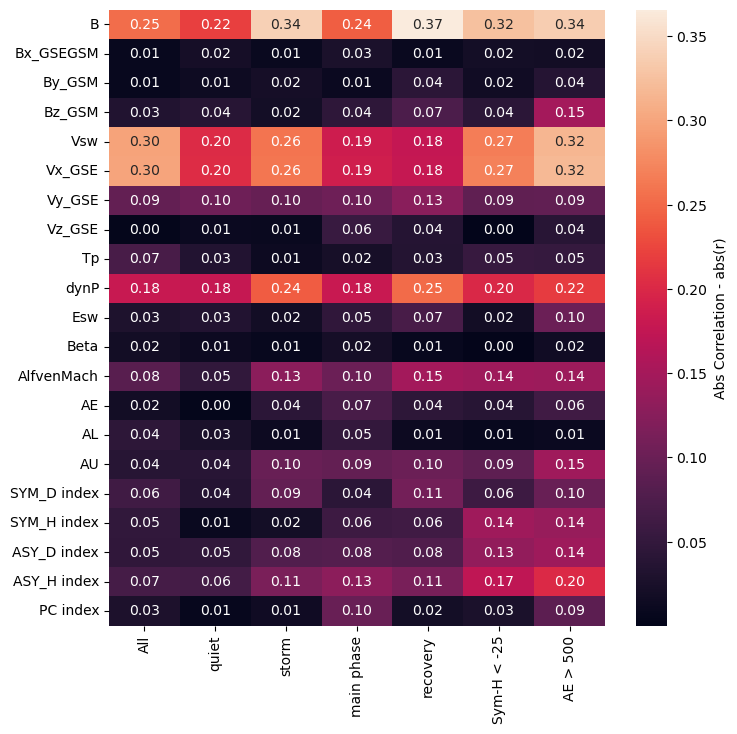

In [158]:
plt.figure(figsize=(8, 8))
sns.heatmap(cor_mat[:-2].abs(),annot=True, fmt='.2f', cbar_kws={'label':'Abs Correlation - abs(r)'})
plt.yticks() 
plt.show()

In [114]:
dat.shape

(1089504, 57)